In [ ]:
!pip -q install "city2graph[cpu]" osmnx contextily scikit-learn 2>/dev/null

import warnings, numpy as np, pandas as pd, geopandas as gpd
warnings.filterwarnings("ignore")
from shapely.geometry import Point
import matplotlib.pyplot as plt

import city2graph as c2g
print("city2graph version:", getattr(c2g, "__version__", "unknown"))
print("PyTorch / PyG available:", c2g.is_torch_available())

import torch
import torch.nn.functional as F
from torch_geometric.nn import SAGEConv, to_hetero
from torch_geometric.utils import to_undirected
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
from sklearn.metrics import accuracy_score, f1_score
from sklearn.decomposition import PCA

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)

In [ ]:
CENTER = (35.6595, 139.7005)
DIST_M = 1100

TAG_QUERIES = {
    "food":      {"amenity": ["restaurant", "cafe", "fast_food", "bar", "pub"]},
    "retail":    {"shop": True},
    "education": {"amenity": ["school", "university", "college", "kindergarten", "library"]},
    "health":    {"amenity": ["hospital", "clinic", "pharmacy", "doctors", "dentist"]},
}

def to_points(gdf):
    g = gdf.copy()
    g["geometry"] = g.geometry.representative_point()
    return g

poi_gdf, segments_gdf = None, None
try:
    import osmnx as ox
    ox.settings.use_cache = True
    ox.settings.log_console = False

    frames = []
    for label, tags in TAG_QUERIES.items():
        try:
            f = ox.features_from_point(CENTER, tags=tags, dist=DIST_M)
            f = f[f.geometry.notna()]
            if len(f):
                f = to_points(f)[["geometry"]].copy()
                f["category"] = label
                frames.append(f)
        except Exception as e:
            print(f"  (skip {label}: {e})")

    if not frames:
        raise RuntimeError("No POIs returned from Overpass.")
    poi_gdf = gpd.GeoDataFrame(pd.concat(frames, ignore_index=True), crs="EPSG:4326")

    G = ox.graph_from_point(CENTER, dist=DIST_M, network_type="walk")
    segments_gdf = ox.graph_to_gdfs(G, nodes=False, edges=True).reset_index(drop=True)[["geometry"]]
    print(f"OSM acquisition OK -> {len(poi_gdf)} POIs, {len(segments_gdf)} street segments")
except Exception as e:
    print(f"OSM unavailable ({e}) -> generating synthetic clustered POIs.")
    rng = np.random.default_rng(SEED)
    cats = list(TAG_QUERIES.keys())
    centers = rng.uniform(-0.01, 0.01, size=(8, 2)) + np.array(CENTER[::-1])
    rows = []
    for ci, c in enumerate(centers):
        dom = cats[ci % len(cats)]
        n = rng.integers(40, 90)
        pts = c + rng.normal(0, 0.0016, size=(n, 2))
        for (lon, lat) in pts:
            cat = dom if rng.random() < 0.75 else rng.choice(cats)
            rows.append({"geometry": Point(lon, lat), "category": cat})
    poi_gdf = gpd.GeoDataFrame(rows, crs="EPSG:4326")
    segments_gdf = None
    print(f"Synthetic dataset -> {len(poi_gdf)} POIs")

if len(poi_gdf) > 700:
    poi_gdf = poi_gdf.sample(700, random_state=SEED).reset_index(drop=True)
metric_crs = poi_gdf.estimate_utm_crs()
poi_gdf = poi_gdf.to_crs(metric_crs).reset_index(drop=True)
if segments_gdf is not None:
    segments_gdf = segments_gdf.to_crs(metric_crs)
print("Class balance:\n", poi_gdf["category"].value_counts())

In [ ]:
poi_gdf["cx"] = poi_gdf.geometry.x
poi_gdf["cy"] = poi_gdf.geometry.y

coords = poi_gdf[["cx", "cy"]].to_numpy()
nn = NearestNeighbors(radius=150.0).fit(coords)
poi_gdf["local_density"] = [len(idx) - 1 for idx in nn.radius_neighbors(coords, return_distance=False)]

if segments_gdf is not None and len(segments_gdf):
    try:
        joined = gpd.sjoin_nearest(poi_gdf[["geometry"]], segments_gdf[["geometry"]],
                                   distance_col="dist_street")
        poi_gdf["dist_street"] = joined.groupby(level=0)["dist_street"].min().reindex(poi_gdf.index).fillna(0.0)
    except Exception:
        poi_gdf["dist_street"] = 0.0
else:
    poi_gdf["dist_street"] = 0.0

poi_gdf["category"] = poi_gdf["category"].astype("category")
poi_gdf["label"] = poi_gdf["category"].cat.codes.astype(int)
CLASS_NAMES = list(poi_gdf["category"].cat.categories)
print("Classes:", CLASS_NAMES)

def graph_stats(name, builder):
    try:
        nodes, edges = builder()
        deg = pd.Series(np.r_[edges.index.get_level_values(0),
                              edges.index.get_level_values(1)]).value_counts()
        return name, len(edges), round(deg.mean(), 2), (nodes, edges)
    except Exception as e:
        return name, f"ERR: {e}", None, None

builders = {
    "KNN (k=8)":  lambda: c2g.knn_graph(poi_gdf, distance_metric="euclidean", k=8, as_nx=False),
    "Delaunay":   lambda: c2g.delaunay_graph(poi_gdf, as_nx=False),
    "Gabriel":    lambda: c2g.gabriel_graph(poi_gdf, as_nx=False),
    "RNG":        lambda: c2g.relative_neighborhood_graph(poi_gdf, as_nx=False),
    "EMST":       lambda: c2g.euclidean_minimum_spanning_tree(poi_gdf, as_nx=False),
    "Waxman":     lambda: c2g.waxman_graph(poi_gdf, distance_metric="euclidean", r0=150, beta=0.6),
}
print("\n--- Proximity graph comparison ---")
print(f"{'graph':<14}{'#edges':>10}{'avg_degree':>12}")
built = {}
for nm, b in builders.items():
    name, ne, avgdeg, payload = graph_stats(nm, b)
    print(f"{name:<14}{str(ne):>10}{str(avgdeg):>12}")
    if payload: built[nm] = payload

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, key in zip(axes, ["KNN (k=8)", "Delaunay", "EMST"]):
    if key in built:
        n_, e_ = built[key]
        e_.plot(ax=ax, linewidth=0.4, color="#3b7dd8", alpha=0.6)
        poi_gdf.plot(ax=ax, markersize=4, color="#d83b5c")
        ax.set_title(key); ax.set_axis_off()
plt.suptitle("Spatial graph topologies on the same POI set", y=1.02)
plt.tight_layout(); plt.show()

In [ ]:
nodes_dict = {}
for cat in CLASS_NAMES:
    sub = poi_gdf[poi_gdf["category"] == cat].copy().reset_index(drop=True)
    nodes_dict[cat] = sub[["geometry", "cx", "cy", "local_density"]]
try:
    _, bridge_edges = c2g.bridge_nodes(nodes_dict, proximity_method="knn", k=3,
                                       distance_metric="euclidean")
    hetero = c2g.gdf_to_pyg(
        nodes_dict, bridge_edges,
        node_feature_cols={cat: ["cx", "cy", "local_density"] for cat in CLASS_NAMES},
    )
    print("\nHeteroData node types:", hetero.node_types)
    print("HeteroData edge types:")
    for et in hetero.edge_types:
        print(f"   {et}: {hetero[et].edge_index.shape[1]} edges")
except Exception as e:
    hetero = None
    print("Heterogeneous build skipped:", e)

nodes, edges = c2g.knn_graph(poi_gdf, distance_metric="euclidean", k=8, as_nx=False)

deg = pd.Series(np.r_[edges.index.get_level_values(0),
                      edges.index.get_level_values(1)]).value_counts()
nodes["degree"] = deg.reindex(nodes.index).fillna(0).astype(float)

for col in ["cx", "cy", "local_density", "dist_street", "label"]:
    if col not in nodes.columns:
        nodes[col] = poi_gdf.loc[nodes.index, col].values

FEATS = ["cx", "cy", "local_density", "dist_street", "degree"]
nodes[FEATS] = StandardScaler().fit_transform(nodes[FEATS].astype(float))

data = c2g.gdf_to_pyg(nodes, edges, node_feature_cols=FEATS, node_label_cols=["label"])
data.edge_index = to_undirected(data.edge_index)
data.x = data.x.float()
y = data.y.long().view(-1)
N, num_classes = data.num_nodes, int(y.max()) + 1
print(f"\nHomogeneous Data: {N} nodes, {data.edge_index.shape[1]} directed-edges, "
      f"{data.x.shape[1]} features, {num_classes} classes")

In [ ]:
perm = torch.randperm(N, generator=torch.Generator().manual_seed(SEED))
n_tr, n_va = int(0.6 * N), int(0.2 * N)
train_mask = torch.zeros(N, dtype=torch.bool); train_mask[perm[:n_tr]] = True
val_mask   = torch.zeros(N, dtype=torch.bool); val_mask[perm[n_tr:n_tr + n_va]] = True
test_mask  = torch.zeros(N, dtype=torch.bool); test_mask[perm[n_tr + n_va:]] = True

class GraphSAGE(torch.nn.Module):
    def __init__(self, in_dim, hidden, out_dim, p=0.3):
        super().__init__()
        self.c1 = SAGEConv(in_dim, hidden)
        self.c2 = SAGEConv(hidden, hidden)
        self.lin = torch.nn.Linear(hidden, out_dim)
        self.p = p
    def forward(self, x, ei, return_emb=False):
        h = F.relu(self.c1(x, ei))
        h = F.dropout(h, p=self.p, training=self.training)
        h = F.relu(self.c2(h, ei))
        out = self.lin(h)
        return (out, h) if return_emb else out

model = GraphSAGE(data.x.shape[1], 64, num_classes)
opt = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=5e-4)

def evaluate(mask):
    model.eval()
    with torch.no_grad():
        pred = model(data.x, data.edge_index).argmax(1)
    yt, yp = y[mask].numpy(), pred[mask].numpy()
    return accuracy_score(yt, yp), f1_score(yt, yp, average="macro")

print("\n--- Training GraphSAGE ---")
best_val, best_state = 0.0, None
for epoch in range(1, 201):
    model.train(); opt.zero_grad()
    out = model(data.x, data.edge_index)
    loss = F.cross_entropy(out[train_mask], y[train_mask])
    loss.backward(); opt.step()
    if epoch % 20 == 0:
        va_acc, va_f1 = evaluate(val_mask)
        if va_acc > best_val:
            best_val, best_state = va_acc, {k: v.clone() for k, v in model.state_dict().items()}
        print(f"epoch {epoch:3d} | loss {loss.item():.3f} | val_acc {va_acc:.3f} | val_f1 {va_f1:.3f}")

if best_state: model.load_state_dict(best_state)
te_acc, te_f1 = evaluate(test_mask)
print(f"\nTEST  accuracy={te_acc:.3f}  macro-F1={te_f1:.3f}")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 104.4/104.4 kB 5.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 33.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 50.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 152.0/152.0 kB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 49.1 MB/s eta 0:00:00
city2graph version: 0.3.1
PyTorch / PyG available: True
OSM acquisition OK -> 2546 POIs, 11092 street segments
Class balance:
 category
food         373
retail       282
health        27
education     18
Name: count, dtype: int64
Classes: ['education', 'food', 'health', 'retail']

--- Proximity graph comparison ---
graph             #edges  avg_degree
KNN (k=8)           3439        9.83
Delaunay            2076        5.95
Gabriel              736         2.3
RNG                  816        2.34
EMST                 697   

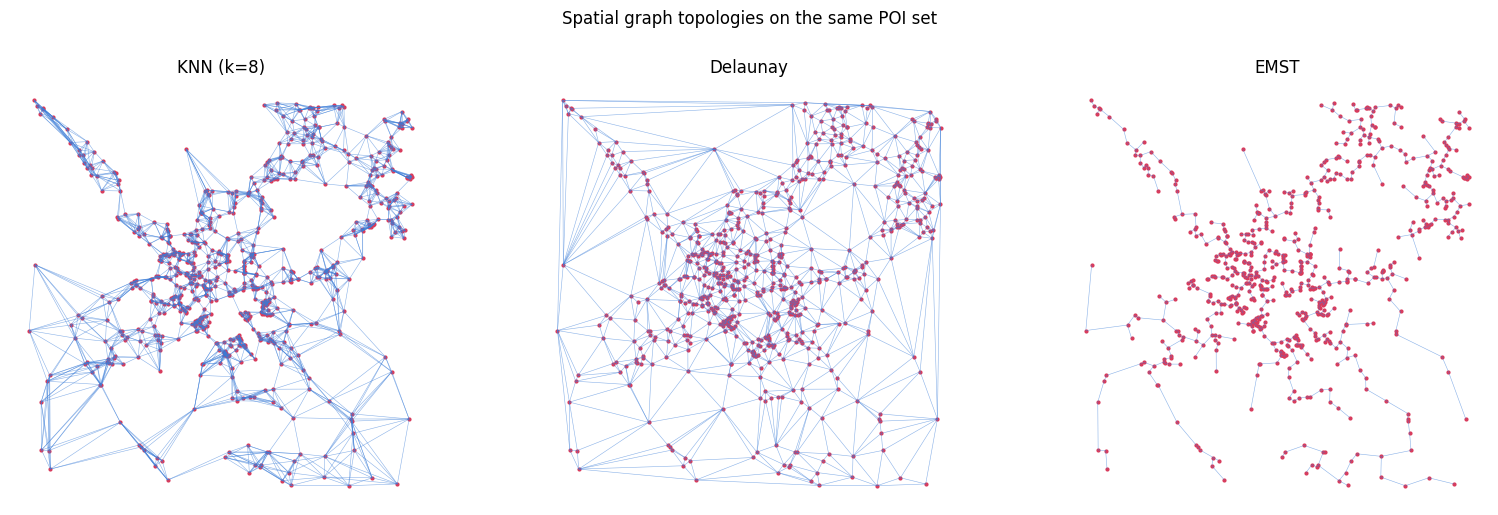


HeteroData node types: ['education', 'food', 'health', 'retail']
HeteroData edge types:
   ('education', 'is_nearby', 'food'): 54 edges
   ('education', 'is_nearby', 'health'): 54 edges
   ('education', 'is_nearby', 'retail'): 54 edges
   ('food', 'is_nearby', 'education'): 1119 edges
   ('food', 'is_nearby', 'health'): 1119 edges
   ('food', 'is_nearby', 'retail'): 1119 edges
   ('health', 'is_nearby', 'education'): 81 edges
   ('health', 'is_nearby', 'food'): 81 edges
   ('health', 'is_nearby', 'retail'): 81 edges
   ('retail', 'is_nearby', 'education'): 846 edges
   ('retail', 'is_nearby', 'food'): 846 edges
   ('retail', 'is_nearby', 'health'): 846 edges

Homogeneous Data: 700 nodes, 6876 directed-edges, 5 features, 4 classes

--- Training GraphSAGE ---
epoch  20 | loss 0.768 | val_acc 0.521 | val_f1 0.266
epoch  40 | loss 0.705 | val_acc 0.564 | val_f1 0.287
epoch  60 | loss 0.648 | val_acc 0.586 | val_f1 0.299
epoch  80 | loss 0.620 | val_acc 0.529 | val_f1 0.334
epoch 100 | los

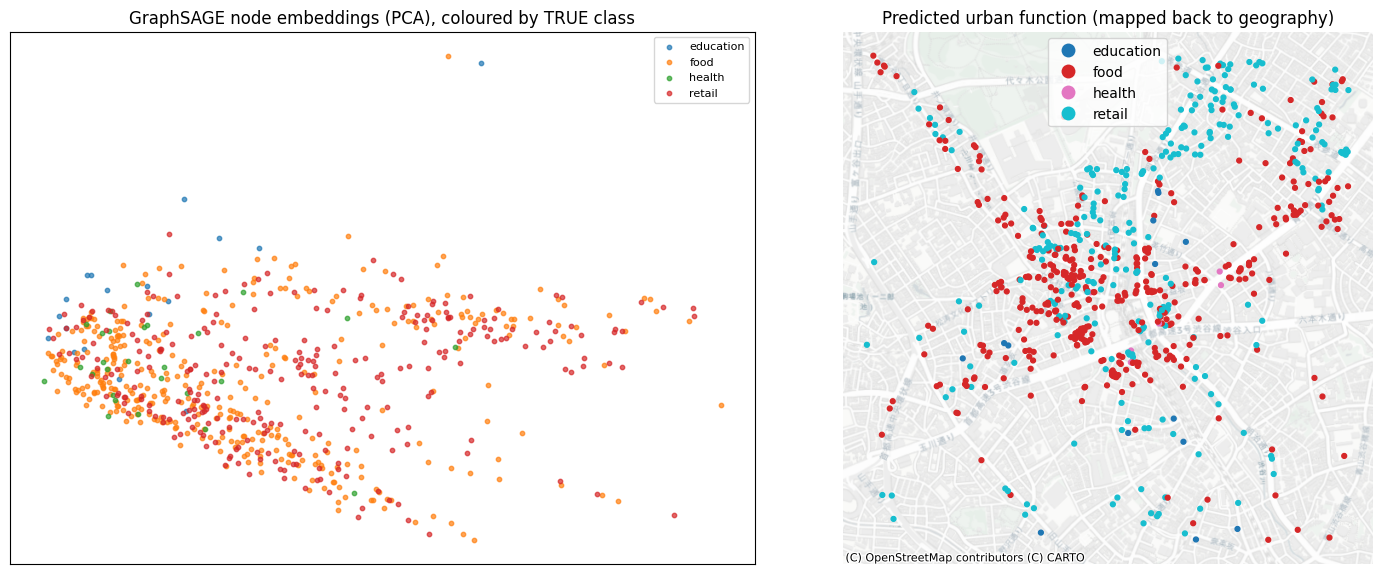

Hetero GNN forward skipped: Proxy object cannot be iterated. This can be attempted when the Proxy is used in a loop or as a *args or **kwargs function argument. See the torch.fx docs on pytorch.org for a more detailed explanation of what types of control flow can be traced, and check out the Proxy docstring for help troubleshooting Proxy iteration errors

✅ Done — proximity comparison, hetero construction, and a trained spatial GNN.


In [ ]:
model.eval()
with torch.no_grad():
    logits, emb = model(data.x, data.edge_index, return_emb=True)
    pred = logits.argmax(1).numpy()

emb2d = PCA(n_components=2).fit_transform(emb.numpy())
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for cls in range(num_classes):
    m = y.numpy() == cls
    axes[0].scatter(emb2d[m, 0], emb2d[m, 1], s=10, label=CLASS_NAMES[cls], alpha=0.7)
axes[0].set_title("GraphSAGE node embeddings (PCA), coloured by TRUE class")
axes[0].legend(fontsize=8); axes[0].set_xticks([]); axes[0].set_yticks([])

plot_gdf = nodes.copy(); plot_gdf["pred"] = pred
plot_gdf["pred_name"] = [CLASS_NAMES[p] for p in pred]
plot_gdf.plot(ax=axes[1], column="pred_name", legend=True, markersize=12, cmap="tab10")
axes[1].set_title("Predicted urban function (mapped back to geography)")
axes[1].set_axis_off()
try:
    import contextily as ctx
    ctx.add_basemap(axes[1], crs=plot_gdf.crs, source=ctx.providers.CartoDB.Positron)
except Exception:
    pass
plt.tight_layout(); plt.show()

if hetero is not None:
    try:
        for nt in hetero.node_types:
            hetero[nt].x = hetero[nt].x.float()
        class HGNN(torch.nn.Module):
            def __init__(self, hid, out):
                super().__init__()
                self.c1 = SAGEConv((-1, -1), hid)
                self.c2 = SAGEConv((-1, -1), out)
            def forward(self, x, ei):
                x = {k: F.relu(v) for k, v in self.c1(x, ei).items()}
                return self.c2(x, ei)
        hmodel = to_hetero(HGNN(32, 16), hetero.metadata(), aggr="sum")
        out_dict = hmodel(hetero.x_dict, hetero.edge_index_dict)
        print("\nHeterogeneous GNN output embedding shapes:")
        for nt, t in out_dict.items():
            print(f"   {nt}: {tuple(t.shape)}")
    except Exception as e:
        print("Hetero GNN forward skipped:", e)

print("\n✅ Done — proximity comparison, hetero construction, and a trained spatial GNN.")